In [1]:
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

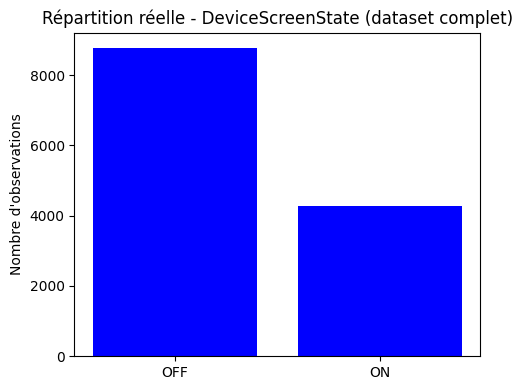

In [3]:
data = TabularDataset("busson20.csv") 
data.columns = data.columns.str.replace(r"[ ()]", "", regex=True)

original_labels = data["DeviceScreenState"].copy()  # Sauvegarde des vraies valeurs

original_counts = data["DeviceScreenState"].value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(original_counts.index.map({0: "OFF", 1: "ON"}), original_counts.values, color=["Blue", "Blue"])
plt.title("Répartition réelle - DeviceScreenState (dataset complet)")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

In [4]:
predictor = TabularPredictor.load("AutogluonModels/ag-20251219_111040")  

In [5]:
predictions = predictor.predict(data, model="LightGBMXT_BAG_L1_FULL")
data["Predicted_Label"] = predictions

In [6]:
data.loc[data["ConnectedDevicesMAC"] == 0, "Predicted_Label"] = 0

In [7]:
data["State"] = 0

Conservative — prioritize experience (less wrong turns)
    N_"TBO" =10(5 min)
	N_"OFF" =5(2.5 min)
	N_"ON" =10(5 min)


In [8]:
# === Propagation initiale ===
N_TBO = 10 # Nombre de lignes à propager après un Predicted_Label = 1
for i in range(len(data)):
    if data.loc[i, "Predicted_Label"] == 1:
        end = min(i + N_TBO, len(data))
        data.loc[i:end, "State"] = 1

# === Extinction et rallumage ===
N_off = 5 # Nombre de lignes à éteindre après un 0
N_on = 10   # Nombre de lignes à rallumer si un 1 est détecté juste après extinction

i = 0
while i < len(data):
    if data.loc[i, "State"] == 0:
        # Extinction : mettre les N_off lignes suivantes à 0
        for j in range(1, N_off + 1):
            if i + j < len(data):
                data.loc[i + j, "State"] = 0

        # Rallumage : si ligne après extinction est 1 rallumer N_on lignes
        if i + N_off < len(data) :
            for k in range(1, N_on + 1):
                if i + N_off + k < len(data):
                    data.loc[i + N_off + k, "State"] = 1

        i += N_off + 1  # avancer après extinction et test de rallumage
    else:
        i += 1

In [9]:
y_true = original_labels
y_pred = data["State"]
y_pred2 = data["Predicted_Label"]

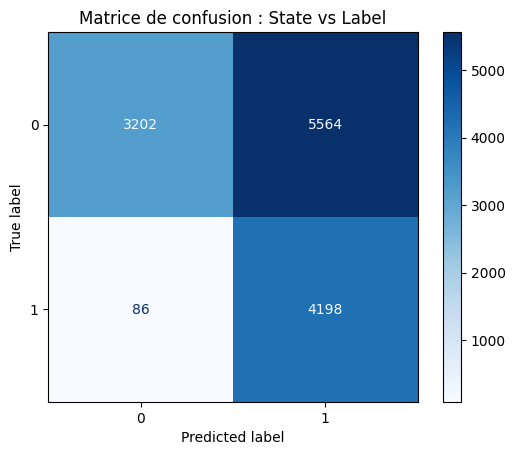

In [10]:
from sklearn.metrics import recall_score
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion : State vs Label")
plt.show()
# Print recall score
recall = recall_score(y_true, y_pred)
#print(f"✅ Recall (classe 1): {recall:.4f}")

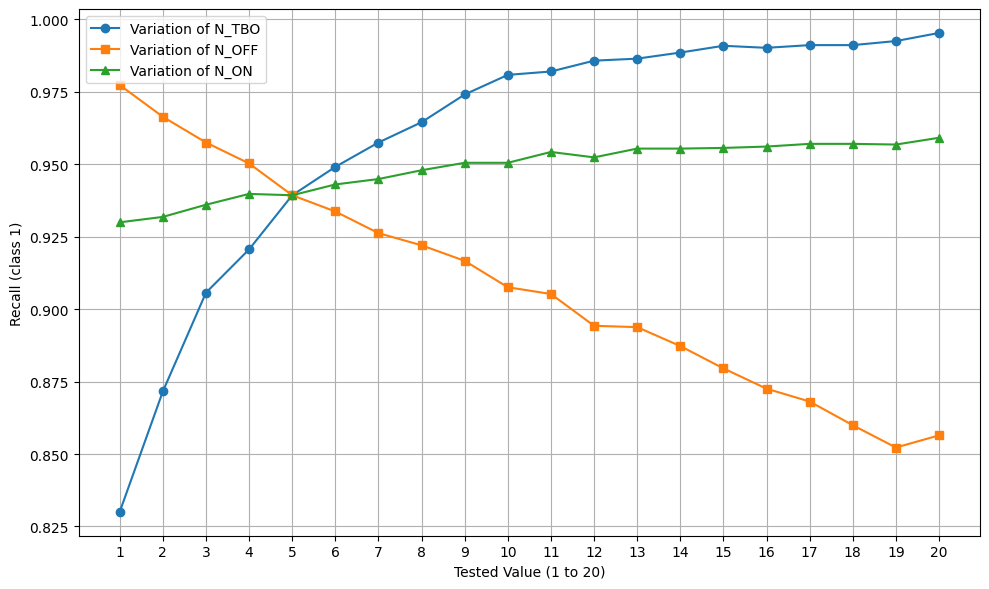

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay

def run_propagation(data, N, N_off, N_on):
    df = data.copy()
    
    # === Initial propagation ===
    for i in range(len(df)):
        if df.loc[i, "Predicted_Label"] == 1:
            end = min(i + N, len(df))
            df.loc[i:end, "State"] = 1

    # === Shutdown and restart ===
    i = 0
    while i < len(df):
        if df.loc[i, "State"] == 0:
            for j in range(1, N_off + 1):
                if i + j < len(df):
                    df.loc[i + j, "State"] = 0

            if i + N_off < len(df):
                for k in range(1, N_on + 1):
                    if i + N_off + k < len(df):
                        df.loc[i + N_off + k, "State"] = 1
            i += N_off + 1
        else:
            i += 1

    return recall_score(original_labels, df["State"])

# === Tests for N, N_off, N_on ===
x_range = list(range(1, 21))
recalls_N = []
recalls_N_off = []
recalls_N_on = []

for val in x_range:
    # Test variation of N (fixed N_off and N_on)
    data["State"] = 0  # Reset
    recalls_N.append(run_propagation(data, N=val, N_off=5, N_on=5))

    # Test variation of N_off
    data["State"] = 0
    recalls_N_off.append(run_propagation(data, N=5, N_off=val, N_on=5))

    # Test variation of N_on
    data["State"] = 0
    recalls_N_on.append(run_propagation(data, N=5, N_off=5, N_on=val))

# === Plotting the graph ===
plt.figure(figsize=(10, 6))
plt.xticks(x_range)
plt.plot(x_range, recalls_N, label="Variation of N_TBO", marker='o')
plt.plot(x_range, recalls_N_off, label="Variation of N_OFF", marker='s')
plt.plot(x_range, recalls_N_on, label="Variation of N_ON", marker='^')
#plt.title("Recall Evolution According to Propagation Parameters")
plt.xlabel("Tested Value (1 to 20)")
plt.ylabel("Recall (class 1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# === Propagation initiale ===
N_TBO = 1 # Nombre de lignes à propager après un Predicted_Label = 1
for i in range(len(data)):
    if data.loc[i, "Predicted_Label"] == 1:
        end = min(i + N_TBO, len(data))
        data.loc[i:end, "State"] = 1

# === Extinction et rallumage ===
N_off = 15 # Nombre de lignes à éteindre après un 0
N_on = 5   # Nombre de lignes à rallumer si un 1 est détecté juste après extinction

i = 0
while i < len(data):
    if data.loc[i, "State"] == 0:
        # Extinction : mettre les N_off lignes suivantes à 0
        for j in range(1, N_off + 1):
            if i + j < len(data):
                data.loc[i + j, "State"] = 0

        # Rallumage : si ligne après extinction est 1 rallumer N_on lignes
        if i + N_off < len(data) :
            for k in range(1, N_on + 1):
                if i + N_off + k < len(data):
                    data.loc[i + N_off + k, "State"] = 1

        i += N_off + 1  # avancer après extinction et test de rallumage
    else:
        i += 1

In [19]:
y_true = original_labels
y_pred = data["State"]
y_pred2 = data["Predicted_Label"]

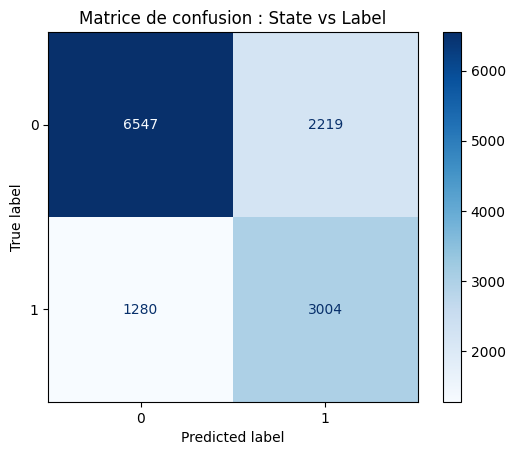

In [20]:
from sklearn.metrics import recall_score
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion : State vs Label")
plt.show()
# Print recall score
recall = recall_score(y_true, y_pred)
#print(f"✅ Recall (classe 1): {recall:.4f}")

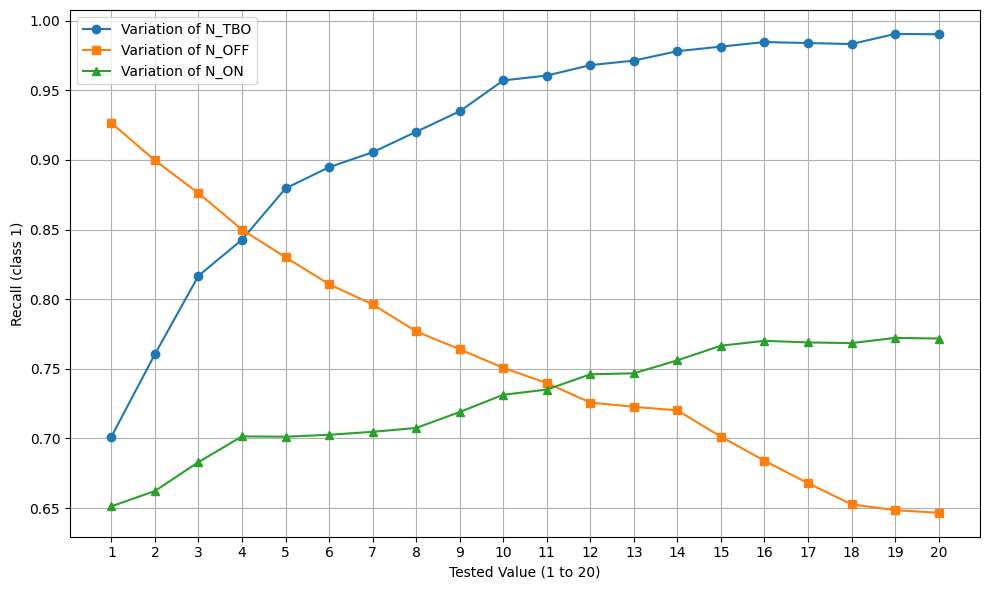

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay

def run_propagation(data, N, N_off, N_on):
    df = data.copy()
    
    # === Initial propagation ===
    for i in range(len(df)):
        if df.loc[i, "Predicted_Label"] == 1:
            end = min(i + N, len(df))
            df.loc[i:end, "State"] = 1

    # === Shutdown and restart ===
    i = 0
    while i < len(df):
        if df.loc[i, "State"] == 0:
            for j in range(1, N_off + 1):
                if i + j < len(df):
                    df.loc[i + j, "State"] = 0

            if i + N_off < len(df):
                for k in range(1, N_on + 1):
                    if i + N_off + k < len(df):
                        df.loc[i + N_off + k, "State"] = 1
            i += N_off + 1
        else:
            i += 1

    return recall_score(original_labels, df["State"])

# === Tests for N, N_off, N_on ===
x_range = list(range(1, 21))
recalls_N = []
recalls_N_off = []
recalls_N_on = []

for val in x_range:
    # Test variation of N (fixed N_off and N_on)
    data["State"] = 0  # Reset
    recalls_N.append(run_propagation(data, N=val, N_off=15, N_on=5))

    # Test variation of N_off
    data["State"] = 0
    recalls_N_off.append(run_propagation(data, N=1, N_off=val, N_on=5))

    # Test variation of N_on
    data["State"] = 0
    recalls_N_on.append(run_propagation(data, N=1, N_off=15, N_on=val))

# === Plotting the graph ===
plt.figure(figsize=(10, 6))
plt.xticks(x_range)
plt.plot(x_range, recalls_N, label="Variation of N_TBO", marker='o')
plt.plot(x_range, recalls_N_off, label="Variation of N_OFF", marker='s')
plt.plot(x_range, recalls_N_on, label="Variation of N_ON", marker='^')
#plt.title("Recall Evolution According to Propagation Parameters")
plt.xlabel("Tested Value (1 to 20)")
plt.ylabel("Recall (class 1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay

def run_propagation(data, N, N_off, N_on):
    df = data.copy()
    
    # === Initial propagation ===
    for i in range(len(df)):
        if df.loc[i, "Predicted_Label"] == 1:
            end = min(i + N, len(df))
            df.loc[i:end, "State"] = 1

    # === Shutdown and restart ===
    i = 0
    while i < len(df):
        if df.loc[i, "State"] == 0:
            for j in range(1, N_off + 1):
                if i + j < len(df):
                    df.loc[i + j, "State"] = 0

            if i + N_off < len(df):
                for k in range(1, N_on + 1):
                    if i + N_off + k < len(df):
                        df.loc[i + N_off + k, "State"] = 1
            i += N_off + 1
        else:
            i += 1

    return recall_score(original_labels, df["State"])

# === Tests for N, N_off, N_on ===
x_range = list(range(1, 21))
recalls_N = []
recalls_N_off = []
recalls_N_on = []

for val in x_range:
    # Test variation of N (fixed N_off and N_on)
    data["State"] = 0  # Reset
    recalls_N.append(run_propagation(data, N=val, N_off=5, N_on=5))

    # Test variation of N_off
    data["State"] = 0
    recalls_N_off.append(run_propagation(data, N=5, N_off=val, N_on=5))

    # Test variation of N_on
    data["State"] = 0
    recalls_N_on.append(run_propagation(data, N=5, N_off=5, N_on=val))

# === Plotting the graph ===
plt.figure(figsize=(10, 6))
plt.xticks(x_range)
plt.plot(x_range, recalls_N, label="Variation of N_TBO", marker='o')
plt.plot(x_range, recalls_N_off, label="Variation of N_OFF", marker='s')
plt.plot(x_range, recalls_N_on, label="Variation of N_ON", marker='^')
#plt.title("Recall Evolution According to Propagation Parameters")
plt.xlabel("Tested Value (1 to 20)")
plt.ylabel("Recall (class 1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 